In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

df = pd.read_csv('Spotify_Youtube.csv')

print("Dataset Shape:", df.shape)
print("\nDataset Columns:", df.columns.tolist())
print("\nMissing Values:\n", df.isna().sum())

Dataset Shape: (20718, 28)

Dataset Columns: ['Unnamed: 0', 'Artist', 'Url_spotify', 'Track', 'Album', 'Album_type', 'Uri', 'Danceability', 'Energy', 'Key', 'Loudness', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Liveness', 'Valence', 'Tempo', 'Duration_ms', 'Url_youtube', 'Title', 'Channel', 'Views', 'Likes', 'Comments', 'Description', 'Licensed', 'official_video', 'Stream']

Missing Values:
 Unnamed: 0            0
Artist                0
Url_spotify           0
Track                 0
Album                 0
Album_type            0
Uri                   0
Danceability          2
Energy                2
Key                   2
Loudness              2
Speechiness           2
Acousticness          2
Instrumentalness      2
Liveness              2
Valence               2
Tempo                 2
Duration_ms           2
Url_youtube         470
Title               470
Channel             470
Views               470
Likes               541
Comments            569
Description        

In [2]:
# Count unique songs and artists
song_cnt = pd.DataFrame({
    "Total Songs": [df["Uri"].nunique()], 
    "Total Artists": [df["Url_spotify"].nunique()]
})
print("\nDataset Overview:")
print(song_cnt)

# Top 10 most streamed songs
print("\nTop 10 Most Streamed Songs:")
print(df.groupby("Track")["Stream"].max().sort_values(ascending=False).head(10))

# Top 10 most viewed videos
print("\nTop 10 Most Viewed Videos:")
print(df.groupby("Track")["Views"].sum().sort_values(ascending=False).head(10))


Dataset Overview:
   Total Songs  Total Artists
0        18862           2079

Top 10 Most Streamed Songs:
Track
Blinding Lights                                  3.386520e+09
Shape of You                                     3.362005e+09
Someone You Loved                                2.634013e+09
rockstar (feat. 21 Savage)                       2.594927e+09
Sunflower - Spider-Man: Into the Spider-Verse    2.538330e+09
One Dance                                        2.522432e+09
Closer                                           2.456205e+09
Believer                                         2.369272e+09
STAY (with Justin Bieber)                        2.365778e+09
Señorita                                         2.336220e+09
Name: Stream, dtype: float64

Top 10 Most Viewed Videos:
Track
Despacito                                         1.615930e+10
See You Again (feat. Charlie Puth)                1.154760e+10
Lean On                                           9.974505e+09
Shape of You  

In [3]:
# Remove URL columns and other non-relevant metadata
url_cols = ['Unnamed: 0', 'Url_spotify', 'Uri', 'Url_youtube', 'Title', 'Description']
df_cleaned = df.drop(url_cols, axis=1)
df_cleaned = df_cleaned.dropna()

# Select numerical columns for analysis
numerical_cols = ['Danceability', 'Energy', 'Key', 'Loudness', 'Speechiness', 
                 'Acousticness', 'Instrumentalness', 'Liveness', 'Valence', 
                 'Tempo', 'Duration_ms', 'Views', 'Likes', 'Comments', 'Stream']

# Display summary statistics
print("\nSummary Statistics for Numerical Features:")
print(df_cleaned[numerical_cols].describe())


Summary Statistics for Numerical Features:
       Danceability        Energy           Key      Loudness   Speechiness  \
count  19549.000000  19549.000000  19549.000000  19549.000000  19549.000000   
mean       0.621059      0.635170      5.294337     -7.633179      0.095392   
std        0.165489      0.213555      3.579338      4.618839      0.106243   
min        0.000000      0.000020      0.000000    -46.251000      0.000000   
25%        0.519000      0.508000      2.000000     -8.772000      0.035700   
50%        0.639000      0.666000      5.000000     -6.516000      0.050700   
75%        0.742000      0.797000      8.000000     -4.929000      0.104000   
max        0.975000      1.000000     11.000000      0.920000      0.964000   

       Acousticness  Instrumentalness      Liveness       Valence  \
count  19549.000000      19549.000000  19549.000000  19549.000000   
mean       0.289106          0.055292      0.191226      0.528950   
std        0.285908          0.192519

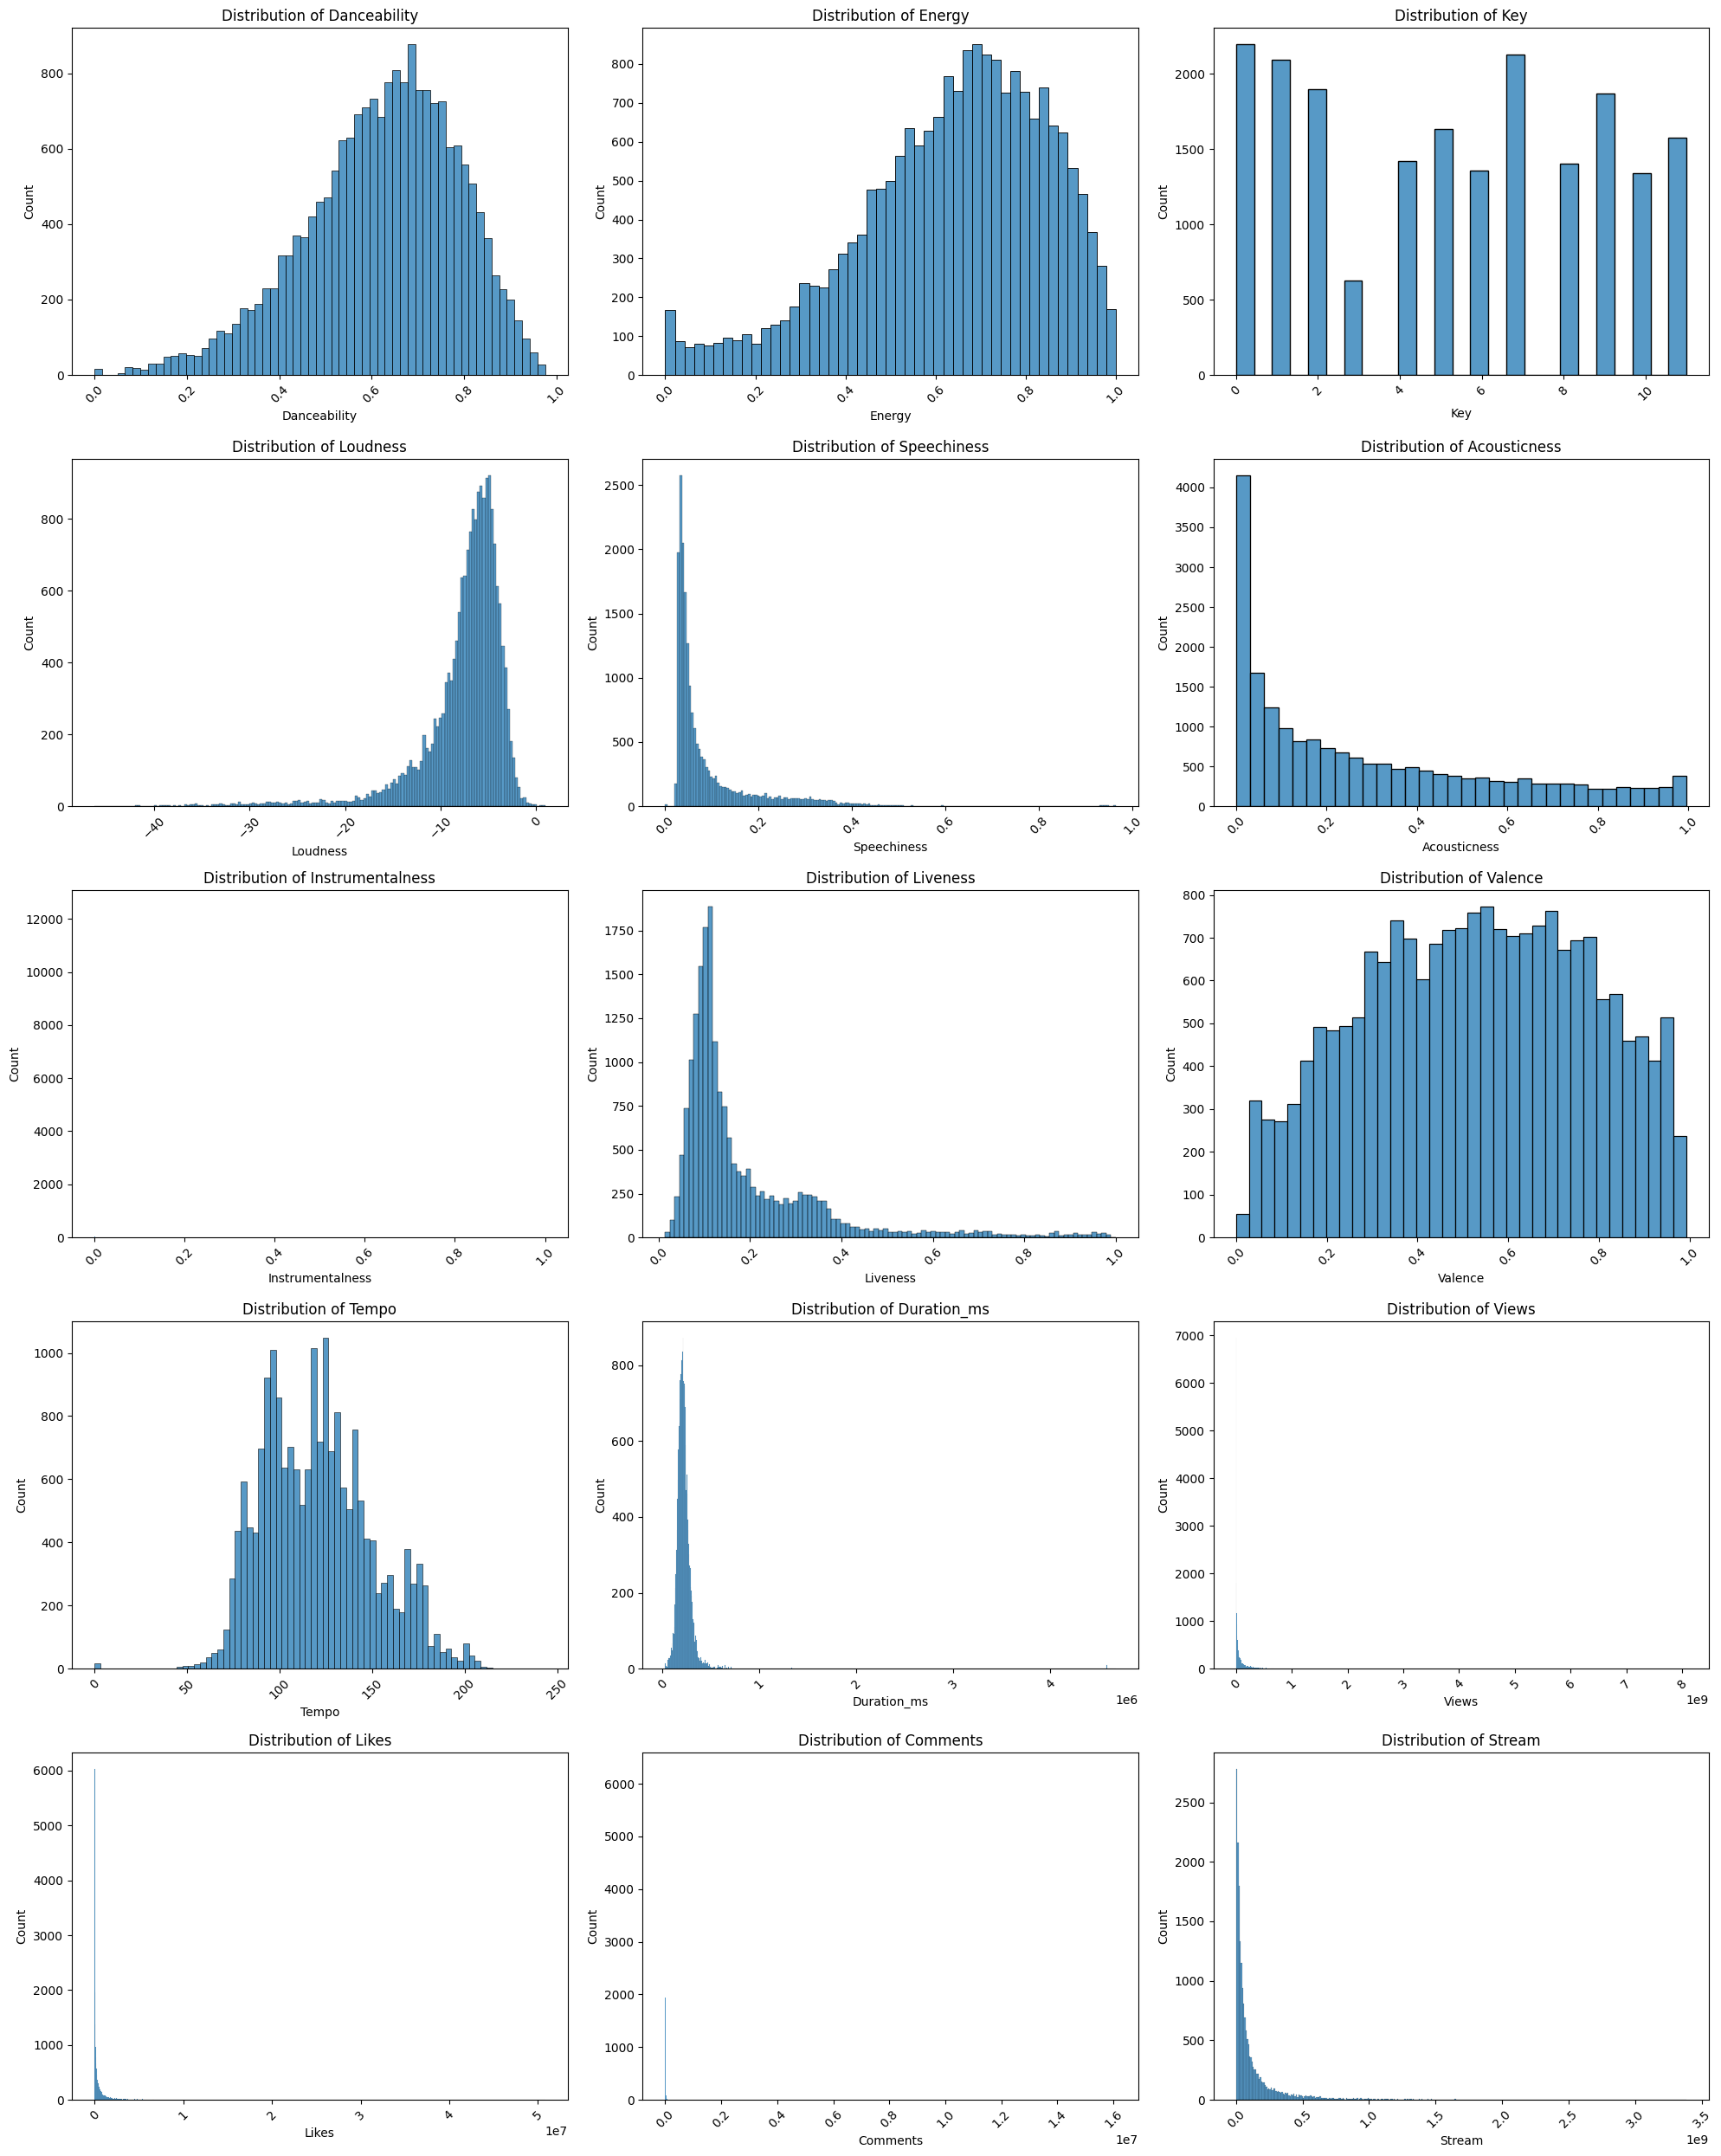

In [4]:
# Create subplots for numerical columns
fig, axes = plt.subplots(5, 3, figsize=(20, 25))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    sns.histplot(data=df_cleaned, x=col, ax=axes[idx])
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import KBinsDiscretizer

# Initialize KBinsDiscretizer
kbd = KBinsDiscretizer(n_bins=4, encode='onehot-dense', strategy='quantile')

# Make sure numerical_cols only has numeric data
numeric_data = df_cleaned[numerical_cols].select_dtypes(include=['float64', 'int64'])
numerical_cols_clean = numeric_data.columns.tolist()

encoded = kbd.fit_transform(df_cleaned[numerical_cols_clean])

# Create column names
col_names = [f'{col}_{i}' for col in numerical_cols_clean for i in range(4)]

# Create DataFrame
binary_df = pd.DataFrame(encoded, columns=col_names[:encoded.shape[1]])
print(binary_df.head())

print("Shape of binary encoded data:", binary_df.shape)
print("\nFirst few columns:", binary_df.columns[:12].tolist())

   Danceability_0  Danceability_1  Danceability_2  Danceability_3  Energy_0  \
0             0.0             0.0             0.0             1.0       0.0   
1             0.0             0.0             1.0             0.0       0.0   
2             0.0             0.0             1.0             0.0       0.0   
3             0.0             0.0             1.0             0.0       0.0   
4             0.0             0.0             1.0             0.0       0.0   

   Energy_1  Energy_2  Energy_3  Key_0  Key_1  ...  Likes_1  Likes_2  Likes_3  \
0       0.0       1.0       0.0    0.0    0.0  ...      0.0      1.0      0.0   
1       0.0       1.0       0.0    0.0    0.0  ...      0.0      1.0      0.0   
2       0.0       0.0       1.0    1.0    0.0  ...      1.0      0.0      0.0   
3       0.0       1.0       0.0    0.0    1.0  ...      0.0      1.0      0.0   
4       0.0       1.0       0.0    0.0    0.0  ...      0.0      1.0      0.0   

   Comments_0  Comments_1  Comments_2 

/Users/raymondchi/.pyenv/versions/3.11.0/lib/python3.11/site-packages/sklearn/preprocessing/_discretization.py:322: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 6 are removed. Consider decreasing the number of bins.
  warnings.warn(


In [15]:
# Generate frequent itemsets
frequent_itemsets = apriori(binary_df, min_support=0.05, use_colnames=True)
print("Number of frequent itemsets found:", len(frequent_itemsets))
print(frequent_itemsets[-15:])

# Generate association rules
rules = association_rules(
  frequent_itemsets, metric="confidence", 
  num_itemsets=binary_df.shape[0],
  min_threshold=0.3,
)
print("\nNumber of rules generated:", len(rules))

# Display top 10 rules by lift
print("\nTop 10 rules by lift:")
print(rules.nlargest(10, 'lift')[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

/Users/raymondchi/.pyenv/versions/3.11.0/lib/python3.11/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Number of frequent itemsets found: 1832
       support                                           itemsets
1817  0.057803       (Views_3, Valence_3, Likes_3, Duration_ms_3)
1818  0.073201         (Views_3, Likes_3, Duration_ms_3, Tempo_3)
1819  0.050591      (Comments_2, Views_2, Likes_2, Duration_ms_0)
1820  0.059185      (Comments_2, Duration_ms_1, Views_2, Likes_2)
1821  0.054274      (Comments_2, Duration_ms_2, Views_2, Likes_2)
1822  0.105632      (Views_3, Likes_3, Duration_ms_3, Comments_3)
1823  0.130953           (Comments_2, Views_2, Stream_2, Likes_2)
1824  0.050335  (Danceability_0, Acousticness_3, Loudness_0, L...
1825  0.051972  (Acousticness_3, Views_3, Loudness_0, Duration...
1826  0.050693  (Likes_3, Acousticness_3, Loudness_0, Duration...
1827  0.052535  (Likes_3, Acousticness_3, Views_3, Loudness_0,...
1828  0.062868  (Likes_3, Views_3, Loudness_0, Duration_ms_3, ...
1829  0.055399  (Likes_3, Acousticness_3, Views_3, Duration_ms...
1830  0.054530  (Likes_3, Acousticne

In [16]:
def analyze_musical_patterns(rules):
    musical_features = ['Danceability', 'Energy']
    
    # Filter rules related to musical features
    musical_rules = rules[
        rules['antecedents'].apply(lambda x: any(f in str(x) for f in musical_features)) &
        rules['consequents'].apply(lambda x: any(f in str(x) for f in musical_features))
    ]
    
    return musical_rules.sort_values('lift', ascending=False)

musical_patterns = analyze_musical_patterns(rules)
print("Top musical patterns:")
print(musical_patterns.head())

Top musical patterns:
                                       antecedents  \
1832                  (Danceability_0, Loudness_0)   
1829        (Energy_0, Liveness_3, Acousticness_3)   
1821  (Danceability_0, Loudness_0, Acousticness_3)   
1839                        (Liveness_3, Energy_0)   
1831              (Danceability_0, Acousticness_3)   

                                       consequents  antecedent support  \
1832        (Energy_0, Liveness_3, Acousticness_3)            0.099238   
1829                  (Danceability_0, Loudness_0)            0.084301   
1821                        (Liveness_3, Energy_0)            0.072331   
1839  (Danceability_0, Loudness_0, Acousticness_3)            0.119188   
1831            (Loudness_0, Liveness_3, Energy_0)            0.102307   

      consequent support   support  confidence      lift  representativity  \
1832            0.084301  0.050335    0.507216  6.016733               1.0   
1829            0.099238  0.050335    0.597087  6.01

In [17]:
def analyze_engagement_patterns(rules, min_lift=1.5):
    # Engagement metrics
    engagement_metrics = ['Views', 'Likes', 'Comments', 'Stream']
    
    # Find rules where musical features lead to engagement
    engagement_rules = rules[
        rules['antecedents'].apply(lambda x: any(f not in str(x) for f in engagement_metrics)) &
        rules['consequents'].apply(lambda x: any(f in str(x) for f in engagement_metrics)) &
        (rules['lift'] >= min_lift)
    ]
    
    return engagement_rules.sort_values('lift', ascending=False)

engagement_patterns = analyze_engagement_patterns(rules)
print("Top patterns leading to high engagement:")
print(engagement_patterns.head())

Top patterns leading to high engagement:
                                      antecedents  \
1848  (Loudness_0, Duration_ms_3, Acousticness_3)   
1863                    (Duration_ms_3, Energy_0)   
1909                          (Views_3, Energy_0)   
1893        (Likes_3, Loudness_0, Acousticness_3)   
1904                          (Likes_3, Energy_0)   

                                consequents  antecedent support  \
1848                    (Views_3, Energy_0)            0.062049   
1863  (Loudness_0, Views_3, Acousticness_3)            0.088189   
1909  (Likes_3, Loudness_0, Acousticness_3)            0.089109   
1893                    (Views_3, Energy_0)            0.063737   
1904  (Loudness_0, Views_3, Acousticness_3)            0.090644   

      consequent support   support  confidence      lift  representativity  \
1848            0.089109  0.051972    0.837593  9.399598               1.0   
1863            0.063277  0.051972    0.589327  9.313465               1.0   
190

In [9]:
def analyze_cross_platform_success(rules):
    # Looking at relationships between Spotify streams and YouTube metrics
    platform_rules = rules[
        (rules['antecedents'].apply(lambda x: 'Stream' in str(x)) & 
         rules['consequents'].apply(lambda x: any(m in str(x) for m in ['Views', 'Likes', 'Comments']))) |
        (rules['antecedents'].apply(lambda x: any(m in str(x) for m in ['Views', 'Likes', 'Comments'])) & 
         rules['consequents'].apply(lambda x: 'Stream' in str(x)))
    ]
    
    return platform_rules.sort_values('lift', ascending=False)

platform_patterns = analyze_cross_platform_success(rules)
print("Cross-platform success patterns:")
print(platform_patterns.head())

Cross-platform success patterns:
                                    antecedents  \
1982  (Comments_2, Instrumentalness_0, Views_2)   
1999                        (Stream_2, Likes_2)   
1806                      (Comments_2, Views_2)   
1811                        (Stream_2, Likes_2)   
1990    (Instrumentalness_0, Stream_2, Likes_2)   

                                    consequents  antecedent support  \
1982                        (Stream_2, Likes_2)            0.117090   
1999  (Comments_2, Instrumentalness_0, Views_2)            0.156734   
1806                        (Stream_2, Likes_2)            0.200164   
1811                      (Comments_2, Views_2)            0.156734   
1990                      (Comments_2, Views_2)            0.095862   

      consequent support   support  confidence      lift  representativity  \
1982            0.156734  0.079748    0.681083  4.345464               1.0   
1999            0.117090  0.079748    0.508812  4.345464               1.0   

In [10]:
def analyze_high_performance(binary_df, df_cleaned):
    # Define high performance thresholds (top quartile)
    stream_threshold = df_cleaned['Stream'].quantile(0.75)
    views_threshold = df_cleaned['Views'].quantile(0.75)
    
    # Find songs that perform well on both platforms
    high_performers = df_cleaned[
        (df_cleaned['Stream'] >= stream_threshold) & 
        (df_cleaned['Views'] >= views_threshold)
    ]
    
    # Get their musical characteristics
    high_performer_features = high_performers[['Danceability', 'Energy', 'Loudness', 
                                             'Acousticness', 'Valence', 'Tempo']]
    
    return high_performer_features.describe()

high_performance_stats = analyze_high_performance(binary_df, df_cleaned)
print("Characteristics of high-performing songs:")
print(high_performance_stats)

Characteristics of high-performing songs:
       Danceability       Energy     Loudness  Acousticness      Valence  \
count   2978.000000  2978.000000  2978.000000   2978.000000  2978.000000   
mean       0.656731     0.678308    -6.039726      0.199999     0.536063   
std        0.151051     0.168000     2.451083      0.219997     0.229068   
min        0.140000     0.111000   -22.320000      0.000005     0.035200   
25%        0.559000     0.570000    -7.244250      0.026700     0.354000   
50%        0.677000     0.696000    -5.609000      0.117000     0.544000   
75%        0.766750     0.805000    -4.341000      0.306750     0.720000   
max        0.975000     0.996000     0.175000      0.989000     0.979000   

             Tempo  
count  2978.000000  
mean    122.573832  
std      29.473952  
min      48.718000  
25%      98.047500  
50%     120.037000  
75%     140.055000  
max     220.099000  


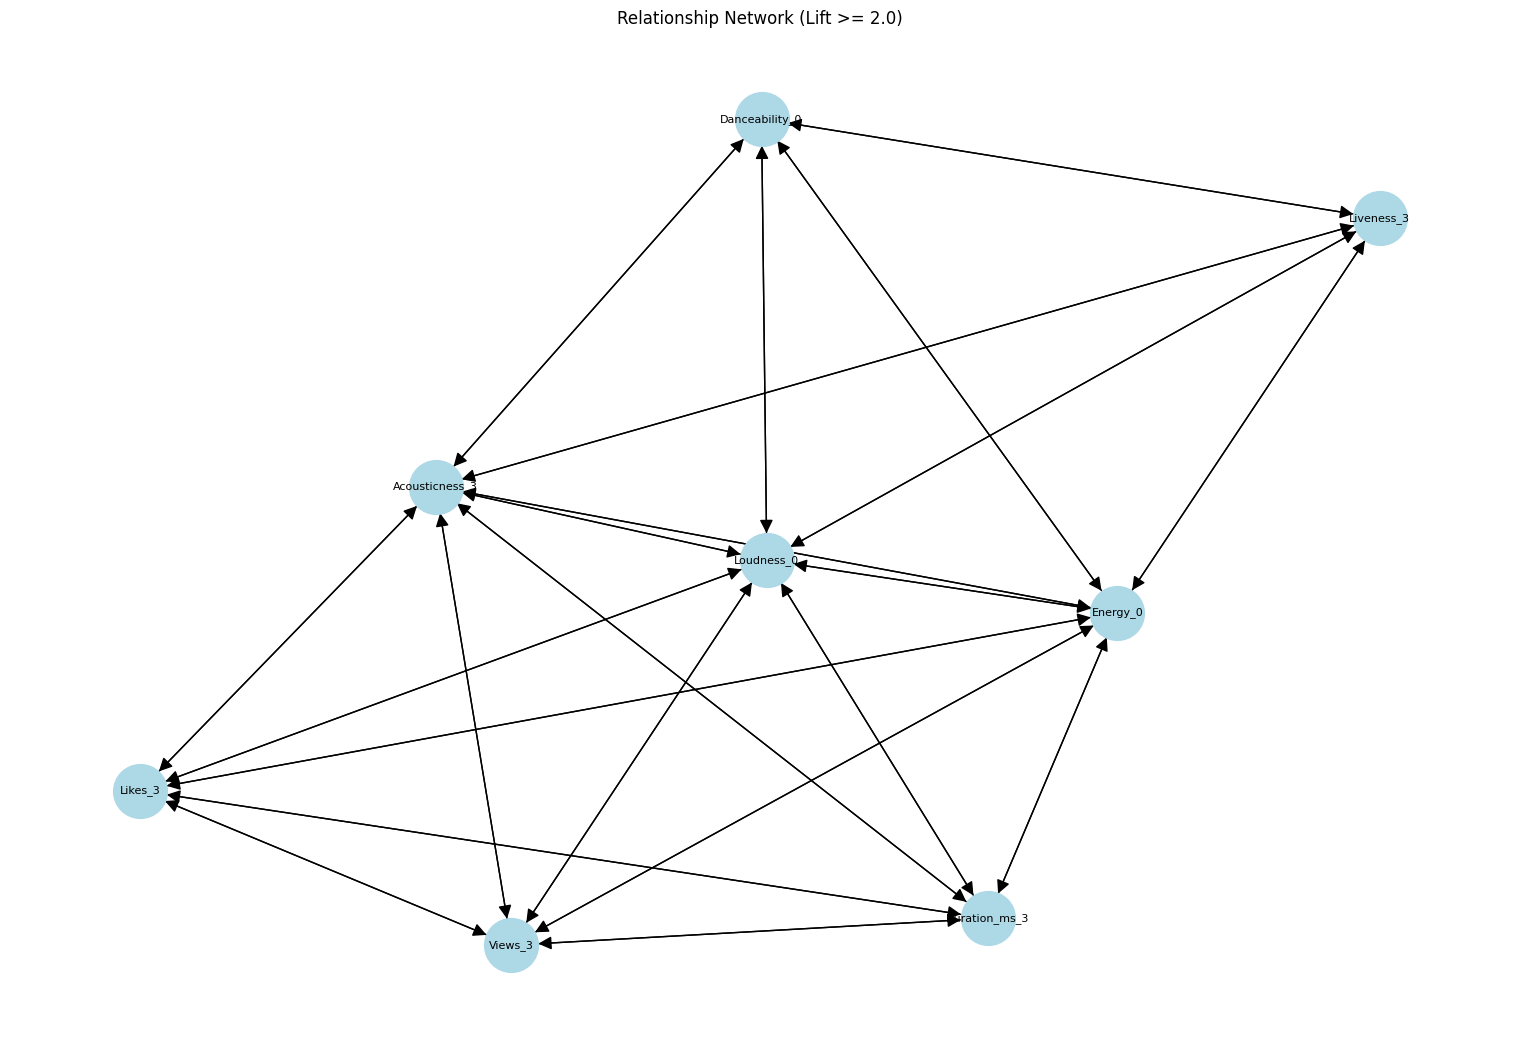

In [42]:
from itertools import product

def visualize_relationship_network(rules, min_lift=6.0):
    import networkx as nx
    
    G = nx.DiGraph()
    
    significant_rules = rules[rules['lift'] >= min_lift]
    
    # Add edges
    for _, rule in significant_rules.iterrows():
        ants = rule['antecedents']
        cons = rule['consequents']
        for ant, con in product(ants, cons):
            G.add_edge(ant, con, weight=rule['lift'])
    
    # Plot
    plt.figure(figsize=(15, 10))
    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_color='lightblue', 
            node_size=1500, arrowsize=20, font_size=8)
    plt.title("Relationship Network (Lift >= 2.0)")
    plt.show()

visualize_relationship_network(rules)

In [ ]:
def analyze_performance_clusters(df_cleaned):

    df_clusters = df_cleaned.copy()
    
    for feature in ['Danceability', 'Energy', 'Acousticness']:
        df_clusters[f'{feature}_level'] = pd.qcut(df_clusters[feature], 
                                                q=4, labels=['Low', 'Medium-Low', 'Medium-High', 'High'])
    
    # Calculate average performance for each combination
    performance_analysis = df_clusters.groupby(['Danceability_level', 'Energy_level'])\
        .agg({
            'Views': 'mean',
            'Likes': 'mean',
            'Stream': 'mean'
        }).round(2)
    
    return performance_analysis

performance_clusters = analyze_performance_clusters(df_cleaned)
print("Performance Analysis by Feature Clusters:")
print(performance_clusters)

Performance Analysis by Feature Clusters:
                                        Views      Likes        Stream
Danceability_level Energy_level                                       
Low                Low           4.775113e+07  361722.49  9.293837e+07
                   Medium-Low    8.907025e+07  597358.75  1.300940e+08
                   Medium-High   8.365412e+07  547865.46  1.295258e+08
                   High          5.993033e+07  388563.29  1.167564e+08
Medium-Low         Low           6.212927e+07  438423.17  1.208450e+08
                   Medium-Low    8.689897e+07  623312.76  1.364429e+08
                   Medium-High   9.304291e+07  676263.65  1.439000e+08
                   High          9.204944e+07  612138.91  1.356669e+08
Medium-High        Low           8.171727e+07  552976.59  1.213541e+08
                   Medium-Low    9.128226e+07  674814.66  1.505221e+08
                   Medium-High   1.207625e+08  875012.53  1.728269e+08
                   High          1.

/var/folders/38/vhxn_3_d46gc6yjxx7zjfcvm0000gn/T/ipykernel_60766/2948553976.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  performance_analysis = df_clusters.groupby(['Danceability_level', 'Energy_level'])\
